In [7]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import joblib
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image as PILImage

from src.config import OUTPUTS, IMG_SIZE, MLP_IMG_SIZE
from src.mlp import MLP, _cargar_split_pca
from src.cnn import CNN
from src.transfer import build_feature_extractor
from src.data import ImageDataset, get_transforms

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. MLP

In [8]:
# Cargar PCA y modelo
pca = joblib.load(OUTPUTS / "pca_mlp.joblib")

model = MLP(input_dim=pca.n_components_)
model.load_state_dict(torch.load(OUTPUTS / "mlp_best.pt", map_location="cpu"))
model.eval()

print(f"Componentes PCA: {pca.n_components_}")
print("Modelo cargado.")

Componentes PCA: 321
Modelo cargado.


In [9]:
# Cargar split de test y obtener predicciones
X_test, y_test = _cargar_split_pca("test", pca)

with torch.no_grad():
    logits = model(X_test)
    y_pred = (logits.sigmoid() >= 0.5).int().squeeze().numpy()

y_true = y_test.squeeze().int().numpy()

Cargando test:   0%|          | 0/5997 [00:00<?, ?it/s]

In [10]:
# Métricas
print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
print(f"F1:        {f1_score(y_true, y_pred):.4f}")

Accuracy:  0.7237
Precision: 0.7017
Recall:    0.7787
F1:        0.7382


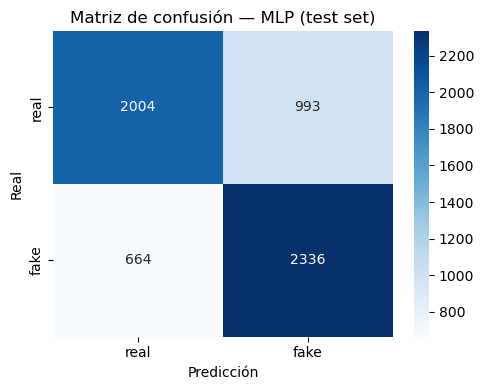

In [11]:
# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["real", "fake"],
            yticklabels=["real", "fake"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión — MLP (test set)")
plt.tight_layout()
plt.show()

### Predicción con imagen propia

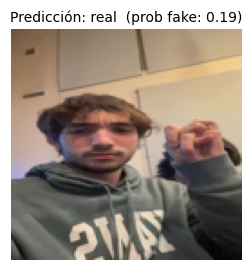

In [12]:
# Cambiá esta ruta por la de tu imagen
ruta = Path("imgs/luca.jpeg")

with PILImage.open(ruta) as img:
    img_resized = img.convert("RGB").resize((MLP_IMG_SIZE, MLP_IMG_SIZE))

x = np.array(img_resized, dtype=np.uint8).flatten().reshape(1, -1)
x_pca = pca.transform(x).astype(np.float32)

with torch.no_grad():
    logit = model(torch.from_numpy(x_pca))
    prob  = logit.sigmoid().item()
    pred  = "fake" if prob >= 0.5 else "real"

plt.figure(figsize=(3, 3))
plt.imshow(img_resized)
plt.title(f"Predicción: {pred}  (prob fake: {prob:.2f})", fontsize=10)
plt.axis("off")
plt.show()

## 2. CNN

In [13]:
cnn_model = CNN()
cnn_model.load_state_dict(torch.load(OUTPUTS / "cnn_best.pt", map_location="cpu"))
cnn_model.eval()
print("CNN cargada.")

CNN cargada.


In [14]:
test_loader = DataLoader(ImageDataset("test"), batch_size=128, shuffle=False)

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        logits = cnn_model(imgs)
        preds  = (logits.sigmoid() >= 0.5).int().squeeze()
        all_preds.append(preds)
        all_labels.append(labels)

y_pred_cnn = torch.cat(all_preds).numpy()
y_true_cnn = torch.cat(all_labels).numpy()

In [15]:
print(f"Accuracy:  {accuracy_score(y_true_cnn, y_pred_cnn):.4f}")
print(f"Precision: {precision_score(y_true_cnn, y_pred_cnn):.4f}")
print(f"Recall:    {recall_score(y_true_cnn, y_pred_cnn):.4f}")
print(f"F1:        {f1_score(y_true_cnn, y_pred_cnn):.4f}")

Accuracy:  0.8843
Precision: 0.9037
Recall:    0.8603
F1:        0.8815


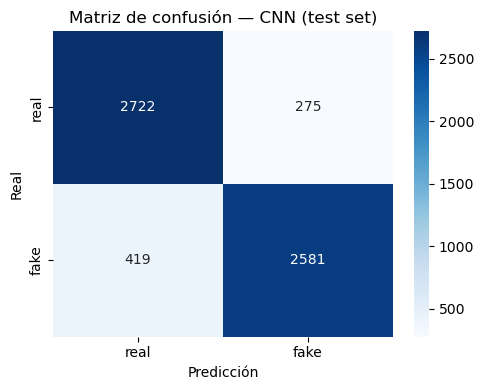

In [16]:
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues",
            xticklabels=["real", "fake"],
            yticklabels=["real", "fake"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión — CNN (test set)")
plt.tight_layout()
plt.show()

### Predicción con imagen propia

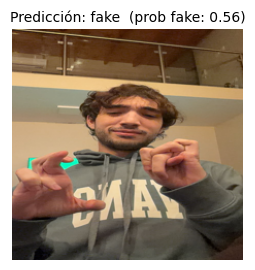

In [17]:
# Cambiá esta ruta por la de tu imagen
ruta = Path("imgs/luca2.jpeg")

with PILImage.open(ruta) as img:
    img_rgb = img.convert("RGB").resize((IMG_SIZE, IMG_SIZE))

transform = get_transforms("val")  # normalización sin augmentation, igual que en test
x = transform(img_rgb).unsqueeze(0)  # (1, 3, 224, 224)

with torch.no_grad():
    logit = cnn_model(x)
    prob  = logit.sigmoid().item()
    pred  = "fake" if prob >= 0.5 else "real"

plt.figure(figsize=(3, 3))
plt.imshow(img_rgb)
plt.title(f"Predicción: {pred}  (prob fake: {prob:.2f})", fontsize=10)
plt.axis("off")
plt.show()

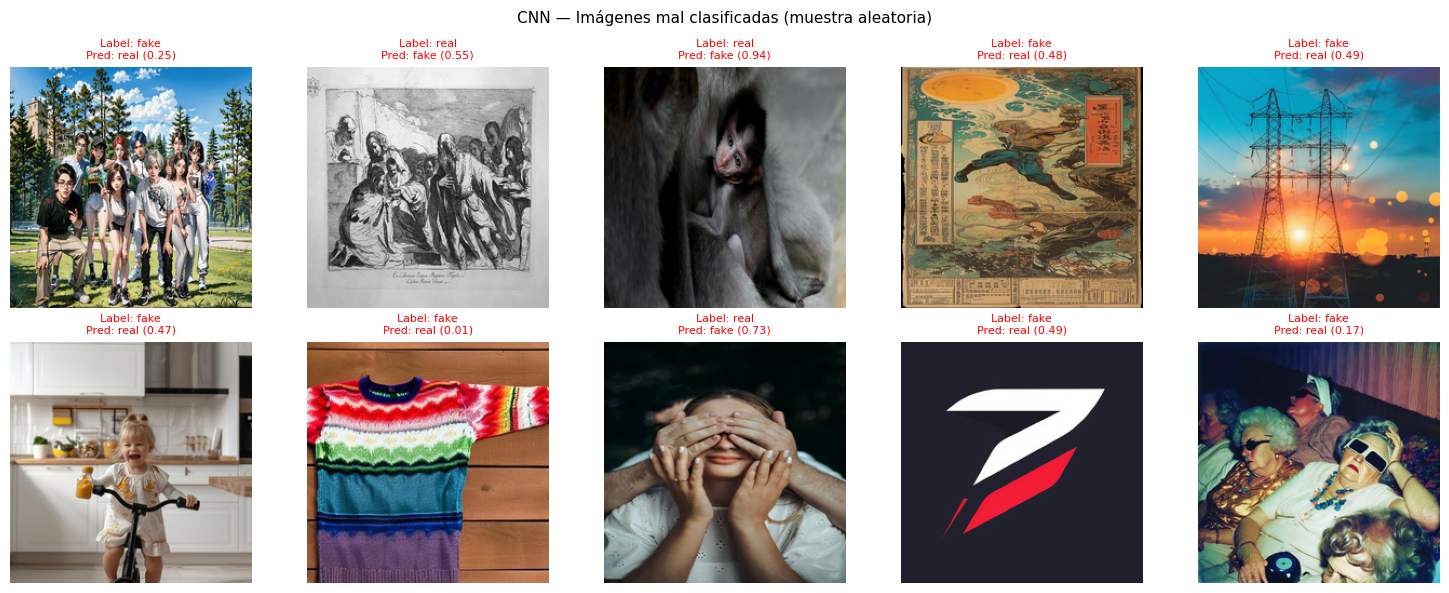

In [18]:
import random
from src.config import IMAGENET_MEAN, IMAGENET_STD

n = 10
dataset      = ImageDataset("test")
INT_TO_LABEL = {0: "real", 1: "fake"}

mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

# Recorre el dataset en orden aleatorio hasta recolectar n mal clasificadas
errores = []
cnn_model.eval()
with torch.no_grad():
    for idx in random.sample(range(len(dataset)), len(dataset)):
        if len(errores) == n:
            break
        img_tensor, label_int = dataset[idx]
        prob = cnn_model(img_tensor.unsqueeze(0)).sigmoid().item()
        pred = "fake" if prob >= 0.5 else "real"
        real = INT_TO_LABEL[label_int]
        if pred != real:
            errores.append((img_tensor, real, pred, prob))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, (img_tensor, real, pred, prob) in enumerate(errores):
    img_np = (img_tensor * std + mean).permute(1, 2, 0).clamp(0, 1).numpy()
    axes[i].imshow(img_np)
    axes[i].set_title(f"Label: {real}\nPred: {pred} ({prob:.2f})", fontsize=8, color="red")
    axes[i].axis("off")

plt.suptitle("CNN — Imágenes mal clasificadas (muestra aleatoria)", fontsize=11)
plt.tight_layout()
plt.show()

In [19]:
import pandas as pd

# Recolecta probabilidades de ser "fake" para cada imagen del test set
all_probs, all_labels_prob = [], []
cnn_model.eval()
with torch.no_grad():
    for imgs, labels in DataLoader(ImageDataset("test"), batch_size=128, shuffle=False):
        probs = cnn_model(imgs).sigmoid().squeeze()
        all_probs.append(probs)
        all_labels_prob.append(labels)

probs_np  = torch.cat(all_probs).numpy()
labels_np = torch.cat(all_labels_prob).numpy()  # 0=real, 1=IA

# Tabla: filas = sub-rangos de probabilidad, columnas = label real
filas = []
for i in range(10):
    lo = round(i / 10, 1)
    hi = round((i + 1) / 10, 1)
    mask = (probs_np >= lo) & (probs_np < hi) if i < 9 else (probs_np >= lo)
    filas.append({
        "Prob. fake":  f"{lo:.1f} – {hi:.1f}",
        "Real":        int(((labels_np == 0) & mask).sum()),
        "IA generada": int(((labels_np == 1) & mask).sum()),
    })

df = pd.DataFrame(filas).set_index("Prob. fake")
df["Total"] = df["Real"] + df["IA generada"]
print(df.to_string())

            Real  IA generada  Total
Prob. fake                          
0.0 – 0.1   1884           79   1963
0.1 – 0.2    359           66    425
0.2 – 0.3    199           78    277
0.3 – 0.4    150          101    251
0.4 – 0.5    130           95    225
0.5 – 0.6     96          173    269
0.6 – 0.7     71          226    297
0.7 – 0.8     48          288    336
0.8 – 0.9     43          399    442
0.9 – 1.0     17         1495   1512


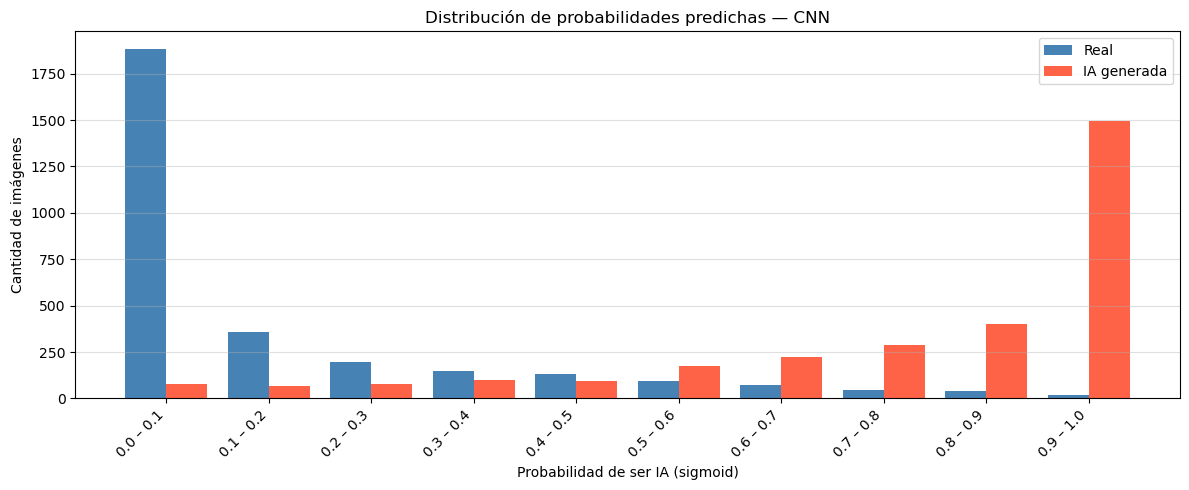

In [20]:
bins  = df.index.tolist()
real  = df["Real"].values
ia    = df["IA generada"].values
x     = range(len(bins))
width = 0.4

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([i - width/2 for i in x], real, width=width, label="Real",        color="steelblue")
ax.bar([i + width/2 for i in x], ia,   width=width, label="IA generada", color="tomato")

ax.set_xticks(list(x))
ax.set_xticklabels(bins, rotation=45, ha="right")
ax.set_xlabel("Probabilidad de ser IA (sigmoid)")
ax.set_ylabel("Cantidad de imágenes")
ax.set_title("Distribución de probabilidades predichas — CNN")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()


## 3. Transfer Learning (ResNet50)

In [21]:
transfer_model = build_feature_extractor()
transfer_model.load_state_dict(torch.load(OUTPUTS / "transfer_best.pt", map_location="cpu"))
transfer_model.eval()
print("Transfer model cargado.")

Transfer model cargado.


In [22]:
test_loader = DataLoader(ImageDataset("test"), batch_size=128, shuffle=False)

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        logits = transfer_model(imgs)
        preds  = (logits.sigmoid() >= 0.5).int().squeeze()
        all_preds.append(preds)
        all_labels.append(labels)

y_pred_tr = torch.cat(all_preds).numpy()
y_true_tr = torch.cat(all_labels).numpy()

In [23]:
print(f"Accuracy:  {accuracy_score(y_true_tr, y_pred_tr):.4f}")
print(f"Precision: {precision_score(y_true_tr, y_pred_tr):.4f}")
print(f"Recall:    {recall_score(y_true_tr, y_pred_tr):.4f}")
print(f"F1:        {f1_score(y_true_tr, y_pred_tr):.4f}")

Accuracy:  0.8808
Precision: 0.8777
Recall:    0.8850
F1:        0.8813


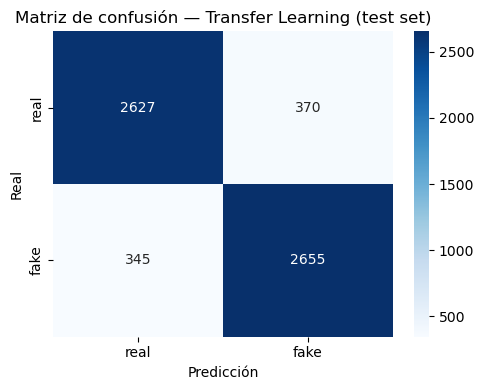

In [24]:
cm_tr = confusion_matrix(y_true_tr, y_pred_tr)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_tr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["real", "fake"],
            yticklabels=["real", "fake"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión — Transfer Learning (test set)")
plt.tight_layout()
plt.show()